# 04 - Explainability: Global, Local, and Partial Dependence (Albania 2022)

How the headline model decides. **Part A** is the global view (SHAP importance, beeswarm, a dependence interaction); **Part B** drills into individual students (representative confusion-matrix cases, local SHAP waterfalls) and the shape of each effect (partial dependence + centered ICE).

## Methods & formulas (reference)

**SHAP (SHapley Additive exPlanations).** Attributes a prediction to features via
the game-theoretic **Shapley value** - the fair payout of feature $i$ averaged
over all orderings:
$$\phi_i=\!\!\sum_{S\subseteq F\setminus\{i\}}\!\!
\frac{|S|!\,(|F|-|S|-1)!}{|F|!}\,\big[f(S\cup\{i\})-f(S)\big].$$
They obey **local accuracy** (additivity): $f(x)=\phi_0+\sum_i\phi_i$, where the
base value $\phi_0=\mathbb{E}[f]$ - contributions plus base reconstruct the
prediction (here in log-odds). **TreeSHAP** computes them *exactly* for tree
ensembles in polynomial time.

**Global importance.** Mean absolute SHAP over the sample,
$\text{Imp}_i=\tfrac1n\sum_k|\phi_i^{(k)}|$ - the average magnitude of feature
$i$'s push on the prediction.

**Beeswarm / dependence.** Each dot is one student's $\phi_i$; a dependence plot
shows $\phi_i$ vs $x_i$ (coloured by an interacting feature) to reveal effect
direction and moderation. SHAP explains the **model** (associational), not
causation.


**Local SHAP (waterfall).** For one student the signed $\phi_i$ (log-odds) stack
from the base value $\phi_0=\mathbb{E}[f]$ to the prediction
$f(x)=\phi_0+\sum_i\phi_i$ (local accuracy). Red $\phi_i>0$ push toward at-risk,
blue $\phi_i<0$ toward proficient.

**Partial Dependence (PDP).** Marginal effect of feature $S$, averaging over the
other features' empirical distribution:
$$\text{PDP}_S(v)=\frac1n\sum_{k=1}^{n} f\big(v,\,x^{(k)}_{\setminus S}\big).$$

**Individual Conditional Expectation (ICE).** One curve per instance,
$\text{ICE}^{(k)}_S(v)=f(v,x^{(k)}_{\setminus S})$; the PDP is their average.
**Centered ICE** anchors each curve at the grid start,
$\text{ICE}^{(k)}(v)-\text{ICE}^{(k)}(v_0)$, so heterogeneous slopes - the
fingerprint of interactions - show up where the average curve hides them.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
try:
    import lightgbm  # noqa: F401 - load its Homebrew libomp BEFORE sklearn's (import-order fix, avoids rc=-11)
except Exception:
    pass
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

---

## Part A — Global SHAP

In [2]:
import shap
from src.models.prepare import build_model_data, impute_median
from src.features.transformers import EngineeredFeatureBuilder
from src.models.registry import get_model
from src.explainability.shap_analysis import compute_shap_values, global_feature_importance

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math', add_school_context=True)
# engineered features (SES_COMPLETE, interactions, ...) built here for the
# final explanatory model (single fit on all data, so fit-on-all is fine)
X_eng = EngineeredFeatureBuilder().fit_transform(data.X)
(X,) = impute_median(X_eng); y = data.y.values
model = get_model('lightgbm'); model.fit(X, y, sample_weight=data.weights.values)
print('trained on', X.shape)

2026-07-08 12:46:17 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-07-08 12:46:18 [info     ] School aggregates added        cols=['ESCS', 'HOMEPOS', 'ANXMAT', 'TEACHSUP'] n_schools=274


2026-07-08 12:46:18 [info     ] Feature selection complete     n_features=18


2026-07-08 12:46:18 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=31 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


trained on (6129, 39)


### 1. Global feature importance (mean |SHAP|)

In [3]:
shap_vals, names = compute_shap_values(model, X,
        X_background=X.sample(min(300, len(X)), random_state=42), max_samples=2000)
imp = global_feature_importance(shap_vals, names)
imp

2026-07-08 12:46:18 [info     ] Subsampling for SHAP           original=6129 sampled=2000


2026-07-08 12:46:18 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


2026-07-08 12:46:18 [info     ] SHAP values computed           shape=(2000, 39)


,feature,mean_abs_shap,rank
0,SCH_MEAN_HOMEPOS,0.281138,1
1,ANXMAT,0.270674,2
2,SCH_MEAN_TEACHSUP,0.242234,3
3,SCH_MEAN_ESCS,0.229600,4
4,HISCED,0.206991,5
5,HOMEPOS,0.198854,6
6,SCH_N,0.197469,7
7,SCH_MEAN_ANXMAT,0.177324,8
8,BELONG,0.156456,9
9,MATERIAL_DEFICIT,0.144264,10


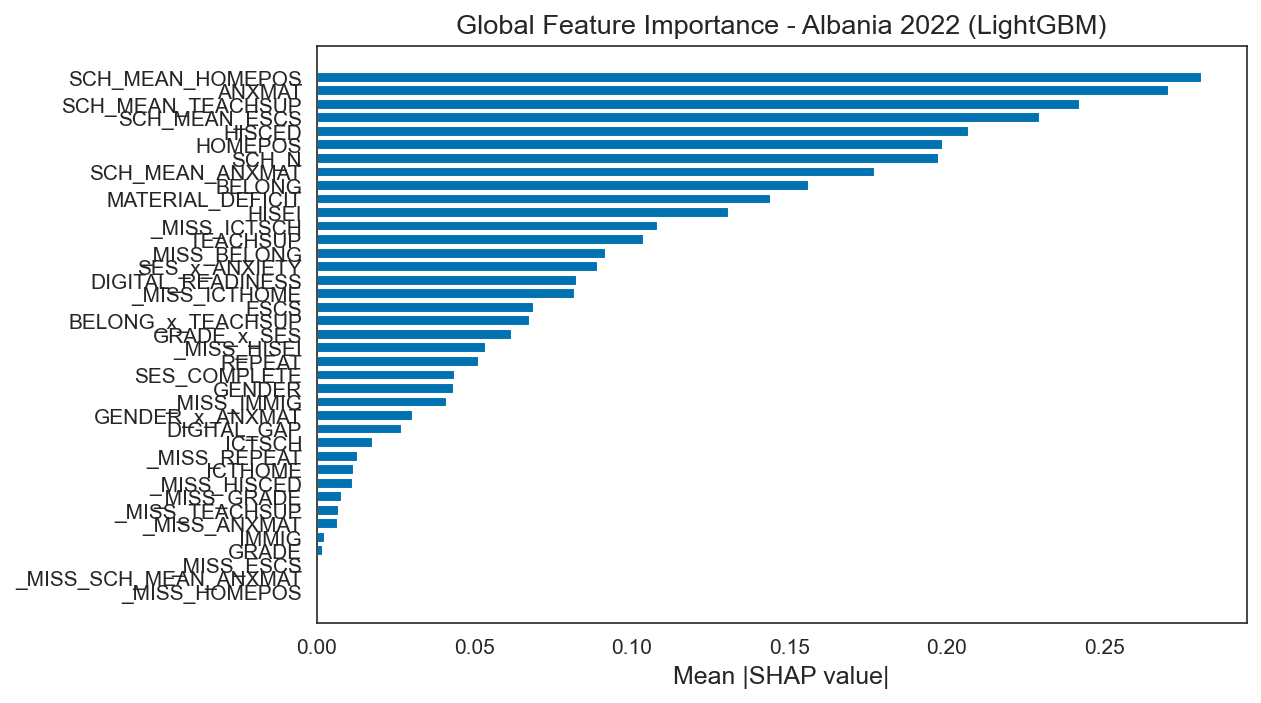

In [4]:
from src.visualization.style import apply_publication_style
apply_publication_style()
imp_s = imp.sort_values('mean_abs_shap')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp_s['feature'], imp_s['mean_abs_shap'], color='#0072B2')
ax.set_xlabel('Mean |SHAP value|'); ax.set_title('Global Feature Importance - Albania 2022 (LightGBM)')
plt.show()

**Reading:** the top drivers are now dominated by **school-level context** - `SCH_MEAN_HOMEPOS` (school mean home possessions) is #1, with `SCH_MEAN_TEACHSUP`, `SCH_MEAN_ESCS` and `SCH_N` (cohort size) all in the top 7. The strongest *individual* factor is `ANXMAT` (math anxiety, #2), then `HISCED`/`HOMEPOS`. The model reads a student's risk more from the socioeconomic composition of their school than from their own resources - the compositional effect made explicit. Immigration and grade deviation still contribute almost nothing.

### 2. SHAP beeswarm - direction of effects

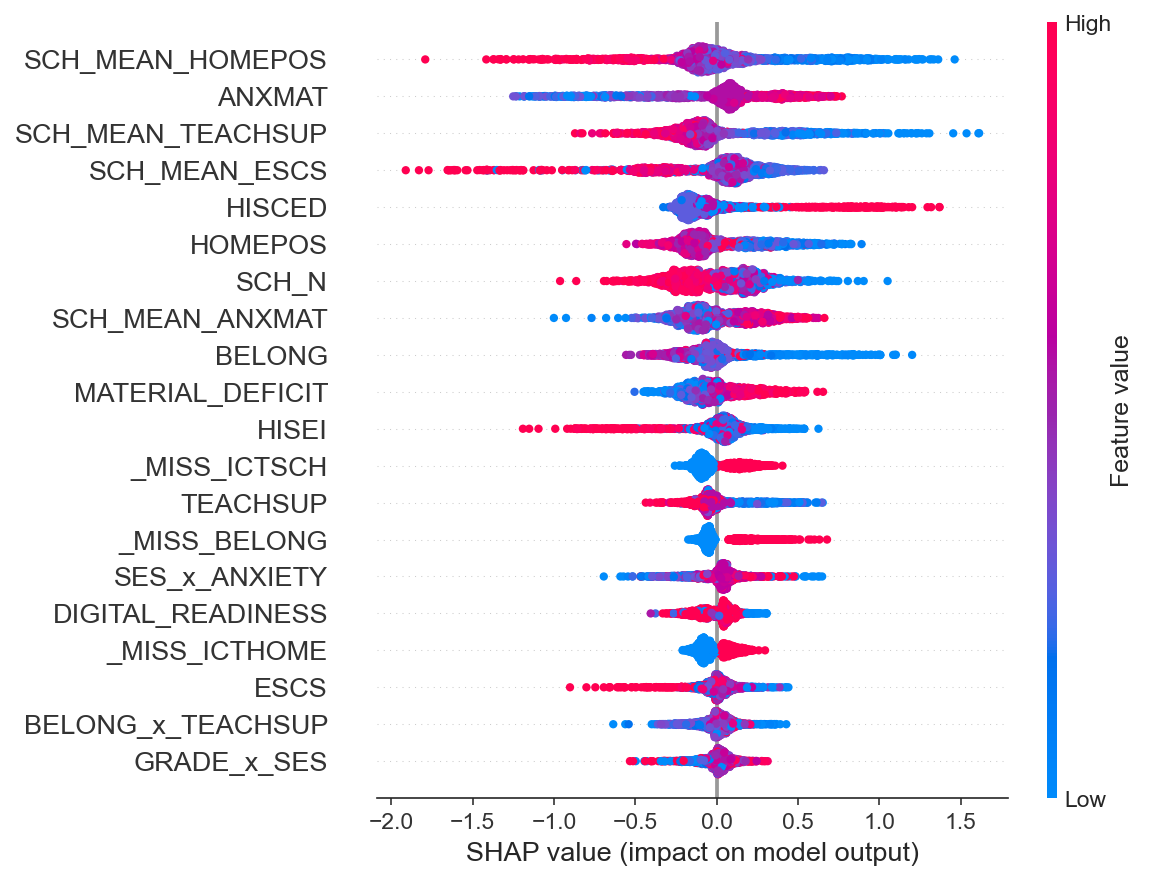

In [5]:
X_s = X.sample(min(2000, len(X)), random_state=42).reset_index(drop=True)
shap.summary_plot(shap_vals, X_s[names], show=True, plot_size=(8,6))

### 3. SHAP dependence - does SES moderate math anxiety?

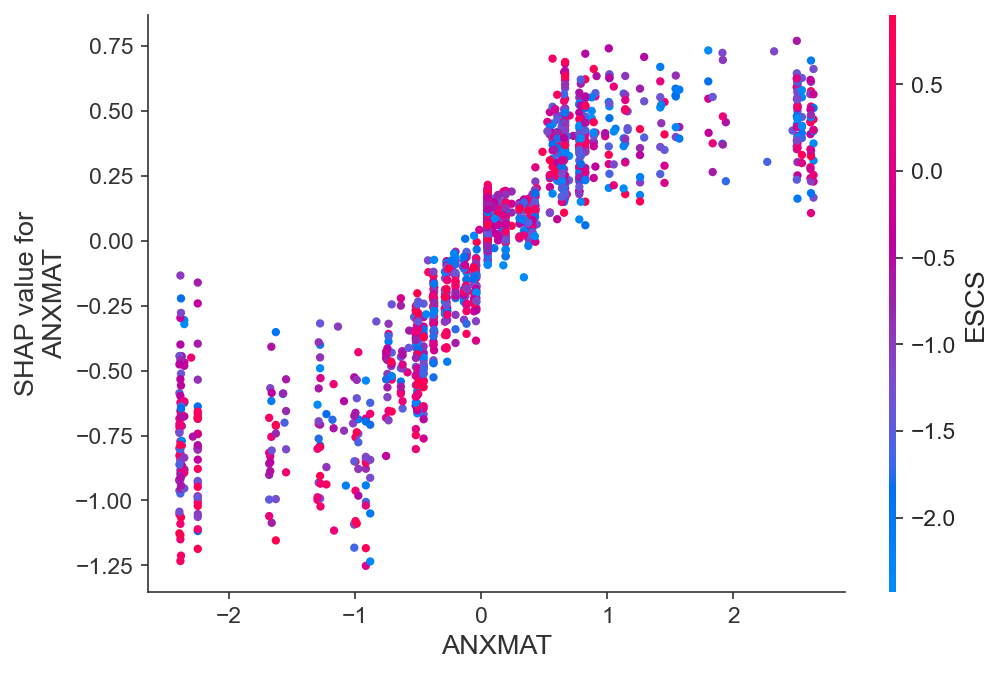

In [6]:
if 'ANXMAT' in names and 'ESCS' in names:
    shap.dependence_plot('ANXMAT', shap_vals, X_s[names], interaction_index='ESCS', show=True)

**Interpretation:** higher math anxiety pushes predictions toward at-risk; the colouring shows whether socioeconomic status buffers or amplifies that effect - a policy-relevant interaction.

### Conclusions & Interpretation

- **School composition dominates (mean |SHAP|):** `SCH_MEAN_HOMEPOS` > `ANXMAT` > `SCH_MEAN_TEACHSUP` > `SCH_MEAN_ESCS` > `HISCED` > `HOMEPOS` > `SCH_N`. Four of the top seven are school-level - the model reads risk more from the *school's* aggregate resources and support than from the student's own.
- **Top individual factor:** `ANXMAT` (math anxiety) is the strongest student-level driver, followed by parental education / home resources (`HISCED`, `HOMEPOS`).
- **Negligible:** immigration status and grade deviation add almost nothing - Albania's risk is a school-context-and-affect story, not a migration one.
- **Policy read:** the highest-leverage levers are *structural* - the socioeconomic segregation of schools and school-level teacher support - alongside individual math anxiety. A pure individual-student intervention misses the dominant, compositional signal. SHAP explains the *model* - associational, not causal.
- **Equity caveat:** because school-mean SES is now a top feature, the model partly encodes *where* a student goes to school; this is exactly the mechanism the fairness audit (notebook 07) probes for the SES gap.
- **Caveat:** explanations are for the single all-data LightGBM fit; per-fold stability and per-country SHAP comparison come in Phase 8.

---

## Part B — Local cases + partial dependence

In [7]:
from src.explainability.shap_analysis import (
    compute_local_shap, compute_shap_values, global_feature_importance,
    select_representative_cases)
from src.explainability.partial_dependence import centered_ice, compute_pdp
from src.features.transformers import EngineeredFeatureBuilder
from src.models.prepare import build_model_data, impute_median
from src.models.registry import get_model

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math', add_school_context=True)
X_eng = EngineeredFeatureBuilder().fit_transform(data.X)
(X,) = impute_median(X_eng); y = data.y.values
model = get_model('lightgbm'); model.fit(X, y, sample_weight=data.weights.values)
print('trained on', X.shape, '| at-risk rate =', round(float(y.mean()),3))

2026-07-08 12:46:19 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-07-08 12:46:19 [info     ] School aggregates added        cols=['ESCS', 'HOMEPOS', 'ANXMAT', 'TEACHSUP'] n_schools=274


2026-07-08 12:46:19 [info     ] Feature selection complete     n_features=18


2026-07-08 12:46:19 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=31 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


trained on (6129, 39) | at-risk rate = 0.754


### 1. Representative confusion-matrix cases

For each quadrant we pick the *most confident* instance - a confidently correct case (TP/TN) and a confidently **wrong** case (FP/FN), whose local SHAP explanation is most informative.

In [8]:
cases = select_representative_cases(model, X, y)
pd.DataFrame([{'quadrant':k, **{kk:vv for kk,vv in c.items() if kk!='index'}}
              for k,c in cases.items()])

,quadrant,label,prob,y_true,y_pred
0,TP,true positive,0.996720,1,1
1,TN,true negative,0.012187,0,0
2,FP,false positive,0.881403,0,1
3,FN,false negative,0.071042,1,0


### 2. Local SHAP waterfalls

Signed feature contributions (log-odds) from the model base value toward each instance's prediction. **Red = pushes toward at-risk, blue = pushes toward proficient.**

2026-07-08 12:46:20 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


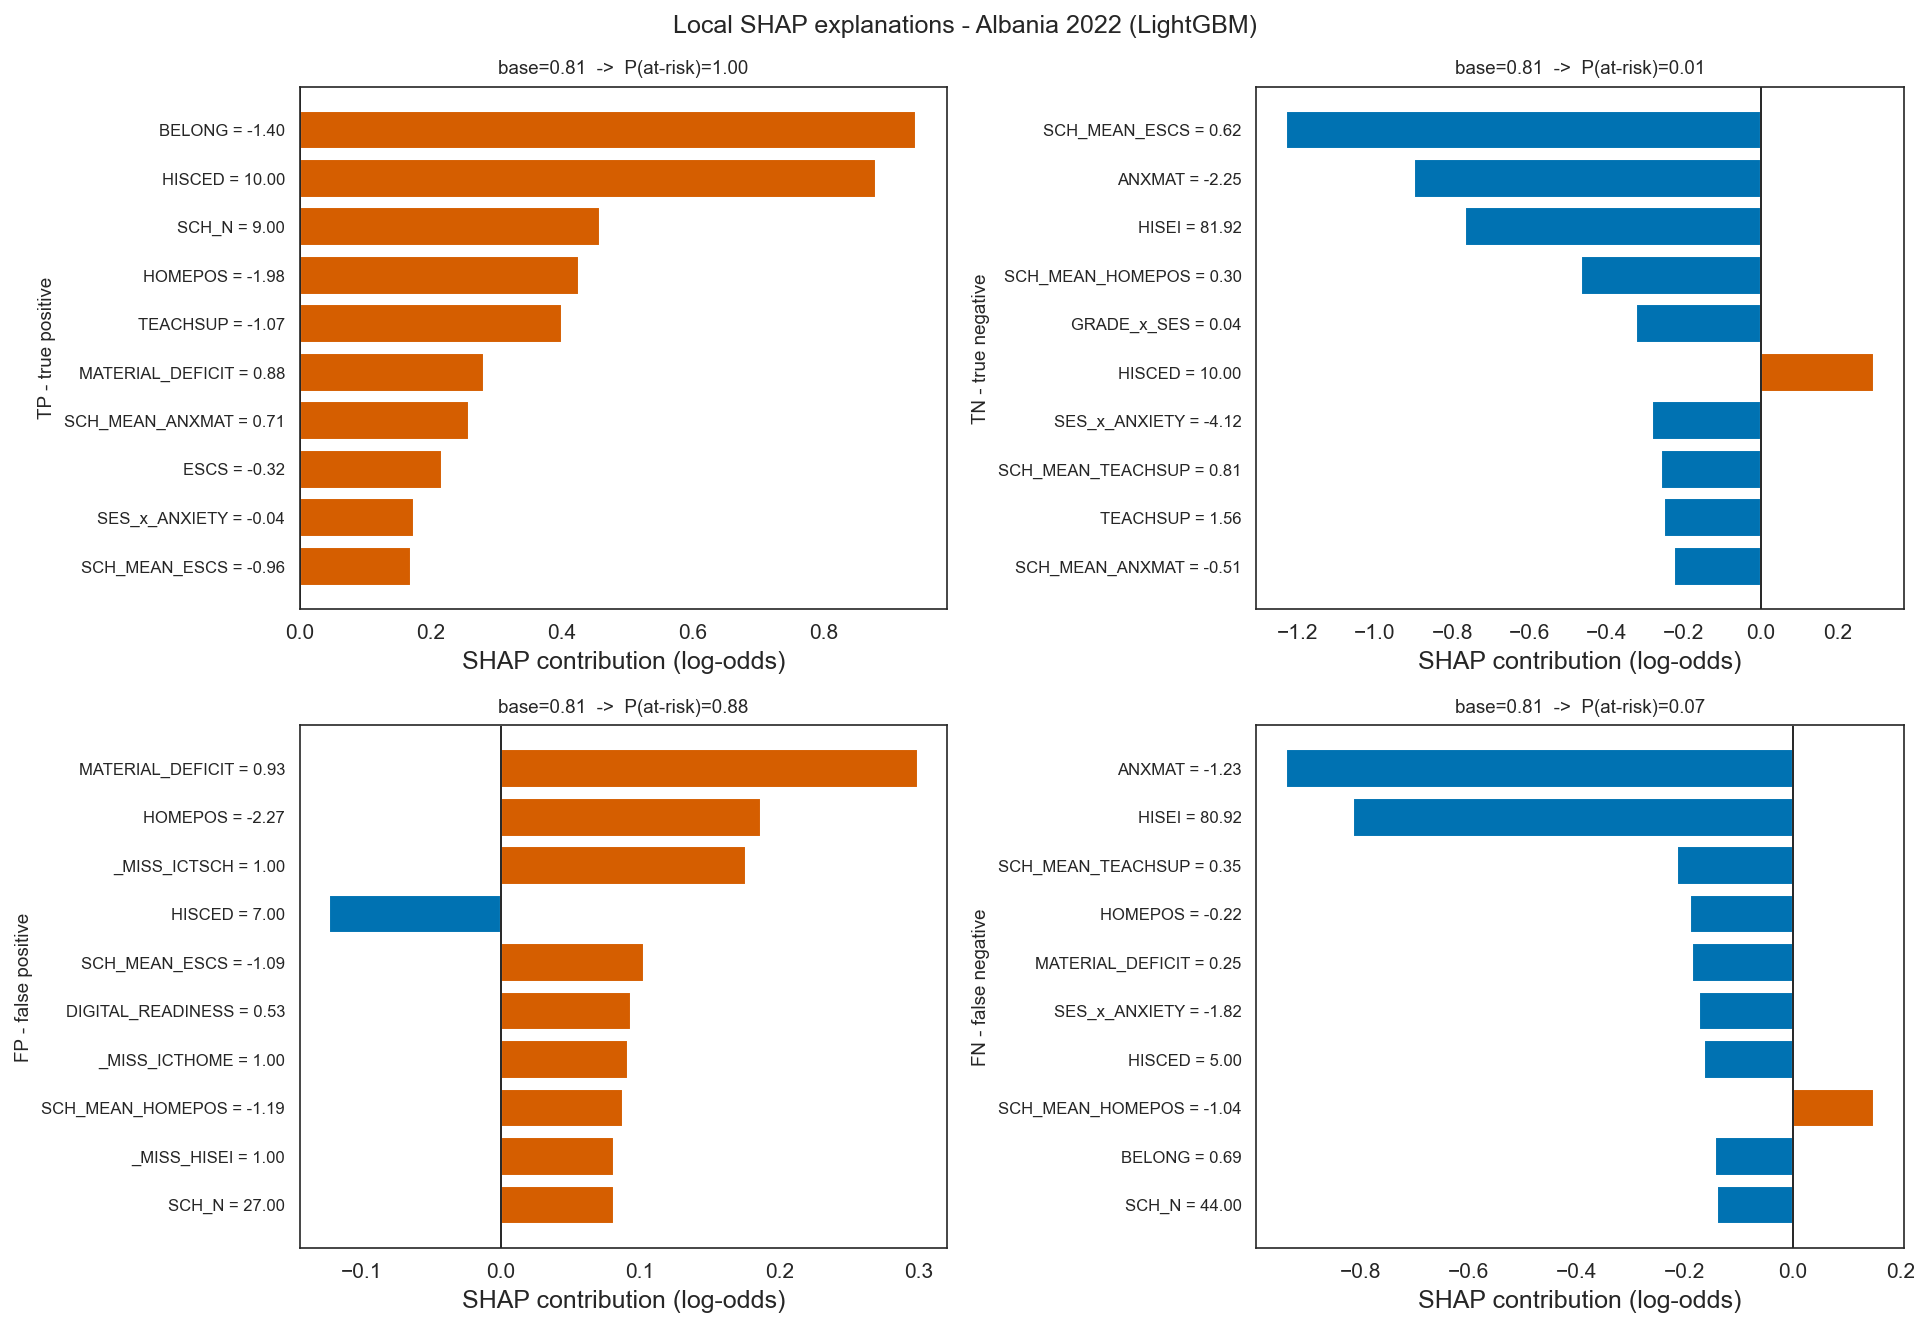

In [9]:
def waterfall(ax, values, base, pred, names, row, top_n=10):
    order = np.argsort(np.abs(values))[::-1][:top_n]
    contrib = values[order]
    labels = [f'{names[i]} = {row[i]:.2f}' for i in order]
    colors = ['#D55E00' if c>0 else '#0072B2' for c in contrib]
    yy = np.arange(len(contrib))[::-1]
    ax.barh(yy, contrib, color=colors); ax.set_yticks(yy)
    ax.set_yticklabels(labels, fontsize=8); ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('SHAP contribution (log-odds)')
    ax.set_title(f'base={base:.2f}  ->  P(at-risk)={pred:.2f}', fontsize=9)

from src.visualization.style import apply_publication_style
apply_publication_style()
idx = [c['index'] for c in cases.values()]
X_bg = X.sample(min(300, len(X)), random_state=42)
vals, base, names = compute_local_shap(model, X.iloc[idx], X_background=X_bg)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (k, c), v, b in zip(axes.ravel(), cases.items(), vals, base):
    waterfall(ax, v, b, c['prob'], names, X.iloc[c['index']].values)
    ax.set_ylabel(f"{k} - {c['label']}", fontsize=9)
fig.suptitle('Local SHAP explanations - Albania 2022 (LightGBM)', fontsize=12)
fig.tight_layout(); plt.show()

**Reading:** the TP/TN waterfalls show the model stacking up **school-context** signals (school-mean home possessions, teacher support, ESCS) alongside individual math anxiety. The FP/FN cases expose where those signals mislead - e.g. a student in a low-resource school who is nonetheless proficient (FP), or a resourced-school student the model misses (FN) - the individual bucking their school context.

### 3. Partial dependence + centered ICE

PDP = mean predicted at-risk probability as one feature varies (all else held). Centered ICE keeps one grey line per instance (anchored to the grid start) so heterogeneity - the fingerprint of interactions - is visible where the average curve hides it.

2026-07-08 12:46:20 [info     ] Subsampling for SHAP           original=6129 sampled=2000


2026-07-08 12:46:20 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


2026-07-08 12:46:20 [info     ] SHAP values computed           shape=(2000, 39)


PDP/ICE for: ['ANXMAT', 'HISCED', 'HOMEPOS', 'BELONG']
2026-07-08 12:46:20 [info     ] PDP computed                   feature=ANXMAT ice=True n_grid=30


2026-07-08 12:46:20 [info     ] PDP computed                   feature=HISCED ice=True n_grid=8


2026-07-08 12:46:20 [info     ] PDP computed                   feature=HOMEPOS ice=True n_grid=30


2026-07-08 12:46:20 [info     ] PDP computed                   feature=BELONG ice=True n_grid=30


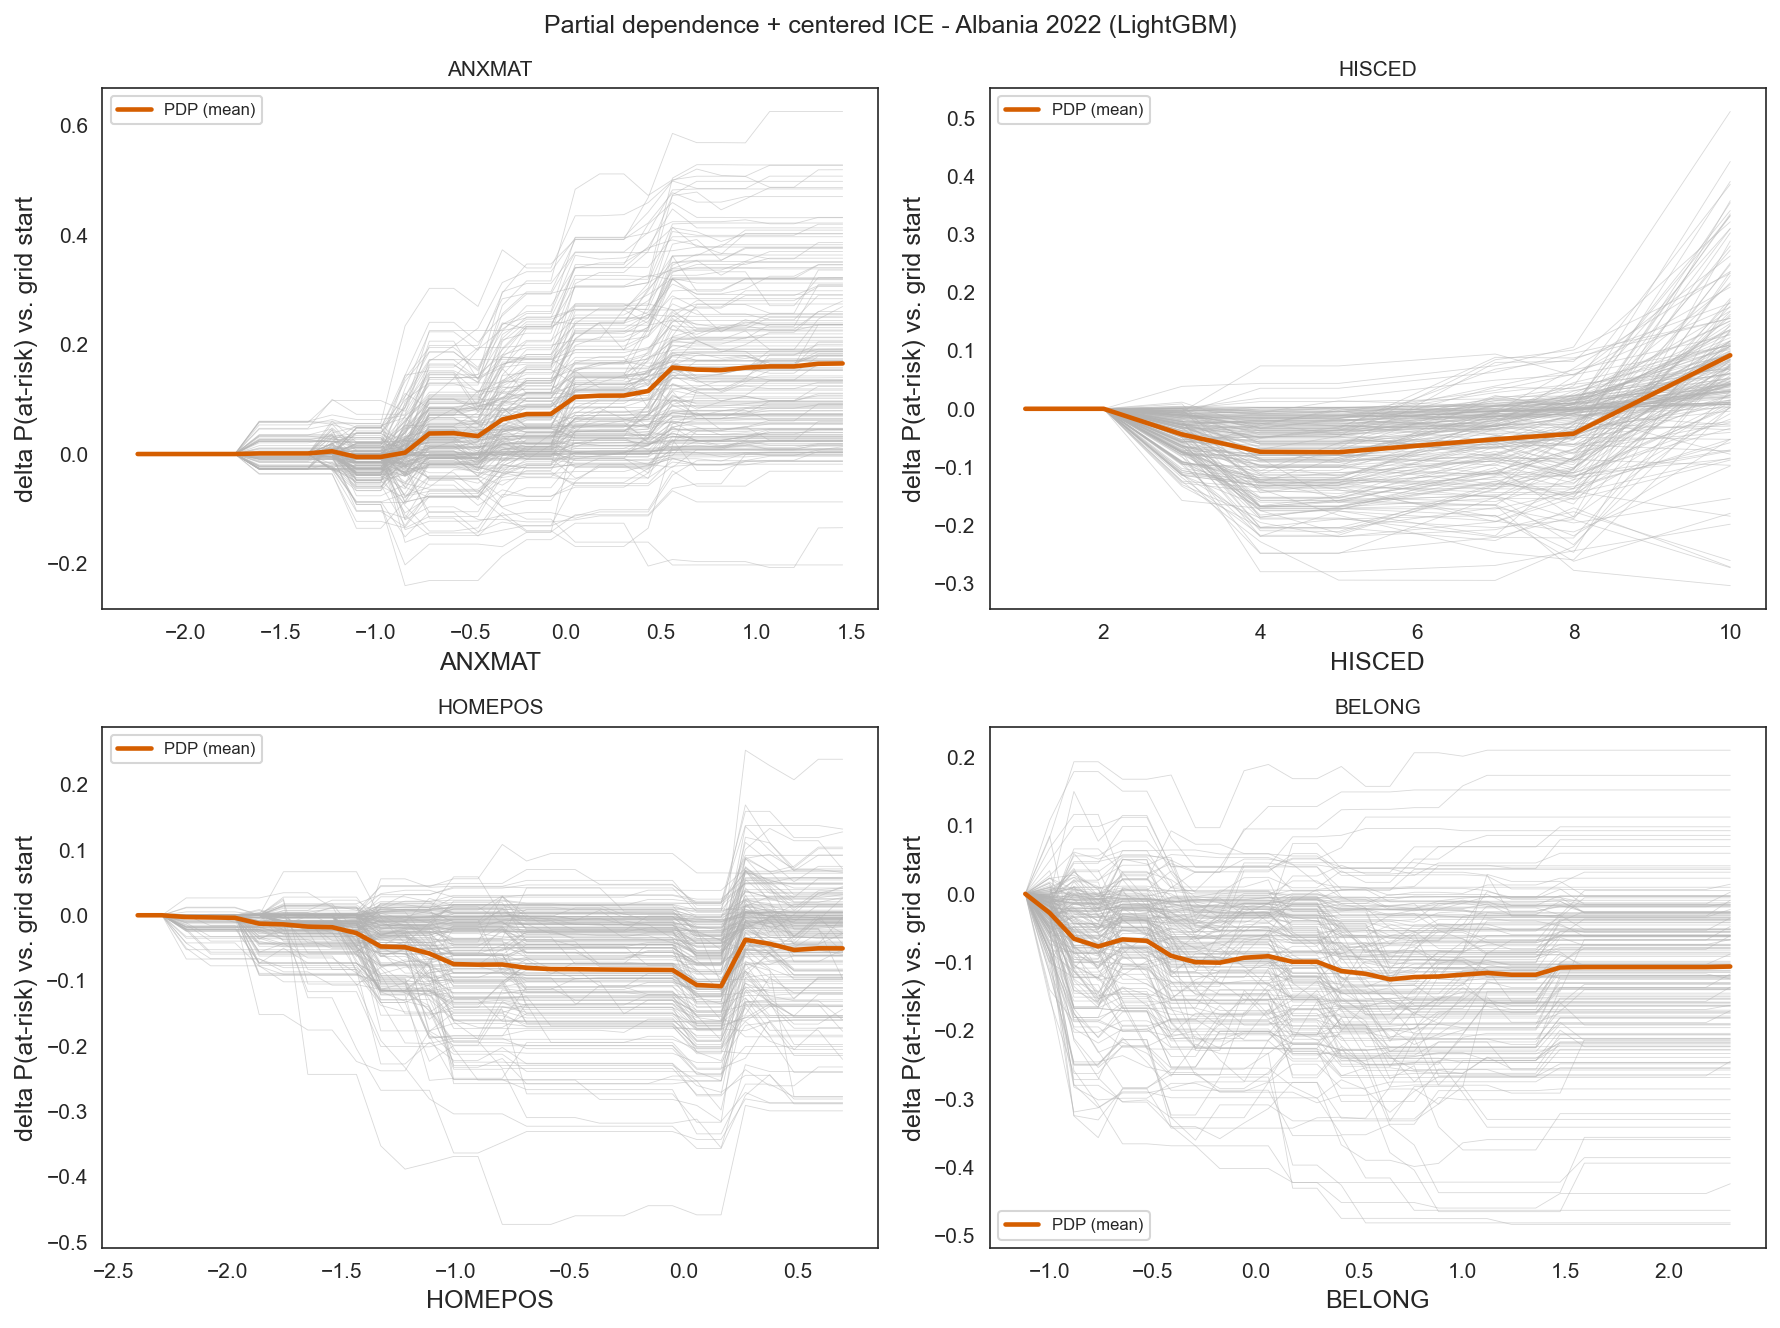

In [10]:
shap_vals, shap_names = compute_shap_values(model, X, X_background=X_bg, max_samples=2000)
imp = global_feature_importance(shap_vals, shap_names)
raw_top = [f for f in imp['feature'] if f in feats][:4]
print('PDP/ICE for:', raw_top)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
rng = np.random.default_rng(42)
for ax, feat in zip(axes.ravel(), raw_top):
    pdp = compute_pdp(model, X, feat, grid_resolution=30, ice=True)
    cice = centered_ice(pdp)
    sub = rng.choice(cice.shape[0], size=min(200, cice.shape[0]), replace=False)
    for r in cice[sub]:
        ax.plot(pdp.grid, r, color='0.7', lw=0.4, alpha=0.5)
    ax.plot(pdp.grid, pdp.average - pdp.average[0], color='#D55E00', lw=2.2, label='PDP (mean)')
    ax.set_title(feat, fontsize=10); ax.set_xlabel(feat)
    ax.set_ylabel('delta P(at-risk) vs. grid start'); ax.legend(fontsize=8)
fig.suptitle('Partial dependence + centered ICE - Albania 2022 (LightGBM)', fontsize=12)
fig.tight_layout(); plt.show()

### Conclusions & Interpretation

- **Local confirms global.** The confidently-correct (TP/TN) waterfalls are dominated by the same drivers notebook 04 flagged globally - **school-context** features (school-mean HOMEPOS/TEACHSUP/ESCS) plus individual math anxiety - so the compositional story isn't an averaging artefact.
- **Where the model fails.** FP/FN cases show the failure mode: the model leans on school context + anxiety, so a student who defies their school's profile (proficient in a low-resource school, or at-risk in a resourced one) is misclassified. Risk is probabilistic, not deterministic, at the individual level.
- **Effect shapes are monotone but heterogeneous.** PDP curves for the top drivers move risk smoothly and roughly monotonically; the ICE spread shows the *magnitude* varies by instance - evidence of interactions (e.g. anxiety's effect moderated by SES).
- **Policy read:** the highest-leverage levers (math anxiety, material support) act on most students but not uniformly - targeting should be individualised, not blanket. Explanations are **associational** (they explain the model), not causal.
- Figures mirror D3 (`D3_shap_local_cases`) and D4 (`D4_pdp_ice`); the case table matches `shap_local_cases_2022.csv`.